Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
file_path = r"C:\Users\Ankita\airfly_insights_dashboard\data\raw\Airline_Dataset_Updated_Final.xlsx"

import pandas as pd

df = pd.read_excel(file_path)

df.head()

,Age,Airport Continent,Airport Country Code,Airport Name,Arrival Airport,Continents,Country Name,Departure Date,First Name,Flight Status,...,Nationality,Passenger ID,Pilot Name,Day of Departure,Time of Departure,Year,Month,Route,IsDelayed,IsCancelled
0,62,NAM,US,Coldfoot Airport,CXF,North America,United States,2022-06-28,Edithe,On Time,...,Japan,ABVWIg,Fransisco Hazeldine,Tuesday,18:46,2022.0,June,Coldfoot Airport - CXF,0,0
1,62,NAM,CA,Kugluktuk Airport,YCO,North America,Canada,2022-12-26,Elwood,On Time,...,Nicaragua,jkXXAX,Marla Parsonage,Monday,14:20,2022.0,December,Kugluktuk Airport - YCO,0,0
2,67,EU,FR,Grenoble-Isère Airport,GNB,Europe,France,2022-01-18,Darby,On Time,...,Russia,CdUz2g,Rhonda Amber,Tuesday,21:34,2022.0,January,Grenoble-Isère Airport - GNB,0,0
3,71,NAM,CA,Ottawa / Gatineau Airport,YND,North America,Canada,2022-09-16,Dominica,Delayed,...,China,BRS38V,Kacie Commucci,Friday,18:50,2022.0,September,Ottawa / Gatineau Airport - YND,1,0
4,21,NAM,US,Gillespie Field,SEE,North America,United States,2022-02-25,Bay,On Time,...,China,9kvTLo,Ebonee Tree,Friday,18:15,2022.0,February,Gillespie Field - SEE,0,0


In [13]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98619 entries, 0 to 98618
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Age                   98619 non-null  int64         
 1   Airport Continent     98619 non-null  object        
 2   Airport Country Code  98619 non-null  object        
 3   Airport Name          98619 non-null  object        
 4   Arrival Airport       98619 non-null  object        
 5   Continents            98619 non-null  object        
 6   Country Name          98619 non-null  object        
 7   Departure Date        59658 non-null  datetime64[ns]
 8   First Name            98619 non-null  object        
 9   Flight Status         98619 non-null  object        
 10  Gender                98619 non-null  object        
 11  Last Name             98619 non-null  object        
 12  Nationality           98619 non-null  object        
 13  Passenger ID    

,Age,Departure Date,Year,IsDelayed,IsCancelled
count,98619.000000,59658,59658.0,98619.000000,98619.000000
mean,45.504021,2022-07-07 01:28:22.061752064,2022.0,0.332907,0.334033
min,1.000000,2022-01-13 00:00:00,2022.0,0.000000,0.000000
25%,23.000000,2022-04-13 00:00:00,2022.0,0.000000,0.000000
50%,46.000000,2022-07-13 00:00:00,2022.0,0.000000,0.000000
75%,68.000000,2022-09-30 00:00:00,2022.0,1.000000,1.000000
max,90.000000,2022-12-30 00:00:00,2022.0,1.000000,1.000000
std,25.929849,NaN,0.0,0.471256,0.471654


In [15]:
print(df.columns)


Index(['Age', 'Airport Continent', 'Airport Country Code', 'Airport Name',
       'Arrival Airport', 'Continents', 'Country Name', 'Departure Date',
       'First Name', 'Flight Status', 'Gender', 'Last Name', 'Nationality',
       'Passenger ID', 'Pilot Name', 'Day of Departure', 'Time of Departure',
       'Year', 'Month', 'Route', 'IsDelayed', 'IsCancelled'],
      dtype='object')


In [16]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Age', 'Airport Continent', 'Airport Country Code', 'Airport Name',
       'Arrival Airport', 'Continents', 'Country Name', 'Departure Date',
       'First Name', 'Flight Status', 'Gender', 'Last Name', 'Nationality',
       'Passenger ID', 'Pilot Name', 'Day of Departure', 'Time of Departure',
       'Year', 'Month', 'Route', 'IsDelayed', 'IsCancelled'],
      dtype='object')


In [17]:
df['Route'] = df['Airport Name'] + " → " + df['Arrival Airport']

ROUTE & AIRPORT ANALYSIS

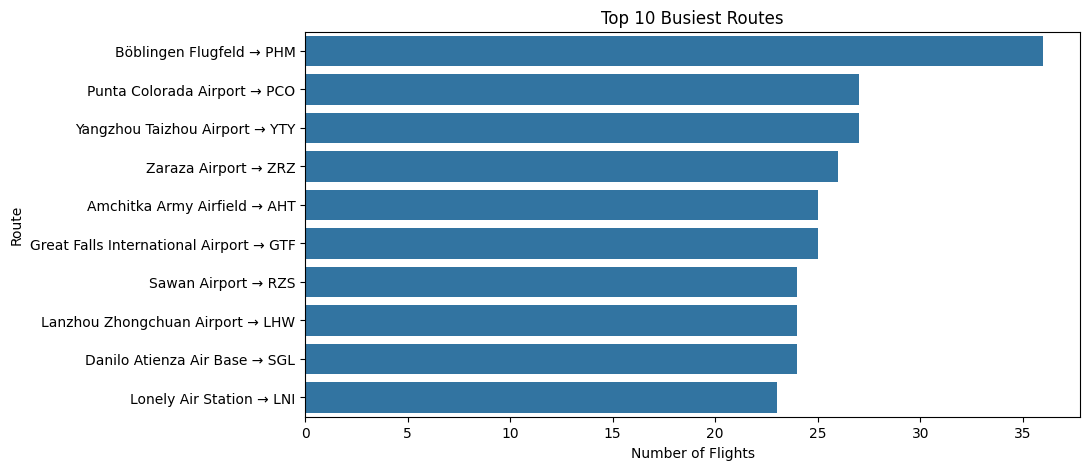

In [18]:
top_routes = df["Route"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_routes.values, y=top_routes.index)
plt.title("Top 10 Busiest Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.show()

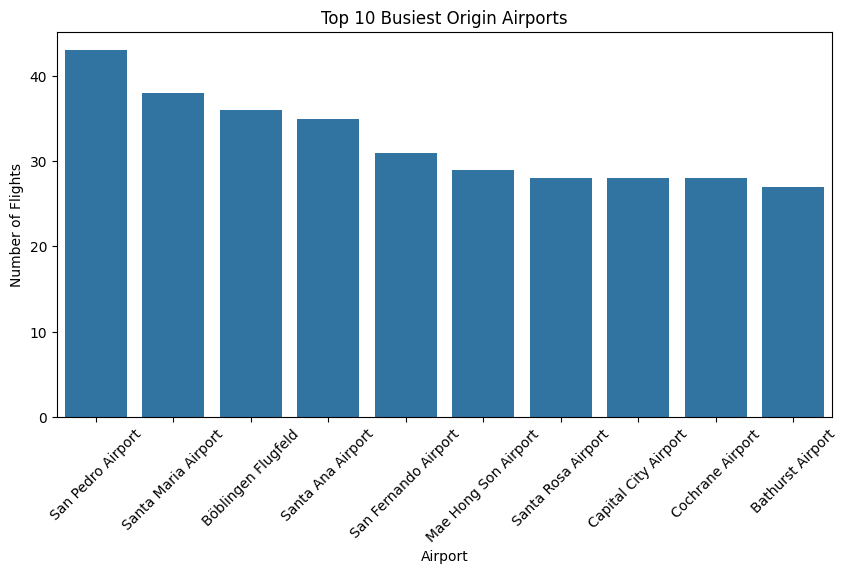

In [20]:
top_airports = df["Airport Name"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_airports.index, y=top_airports.values)
plt.title("Top 10 Busiest Origin Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

Delay Heatmap (Route vs Month)

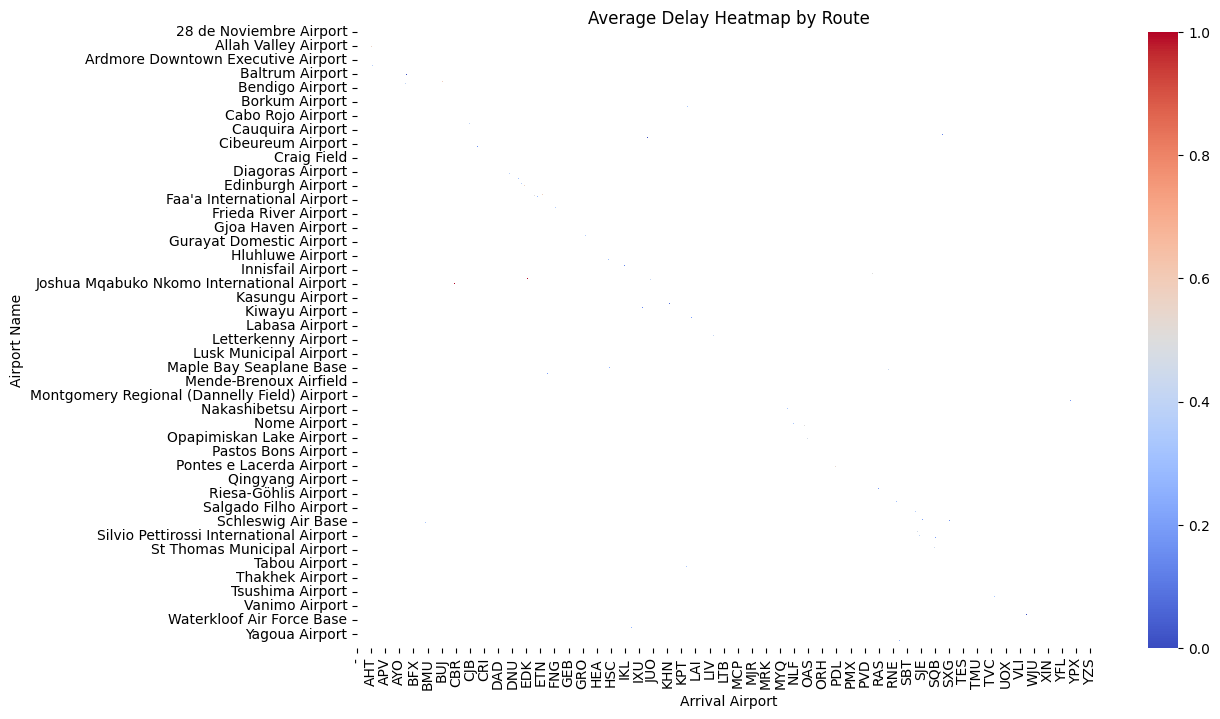

In [22]:
delay_airport = df.pivot_table(
    values="IsDelayed",
    index="Airport Name",
    columns="Arrival Airport",
    aggfunc="mean"
)

plt.figure(figsize=(12,8))
sns.heatmap(delay_airport, cmap="coolwarm")
plt.title("Average Delay Heatmap by Route")
plt.show()

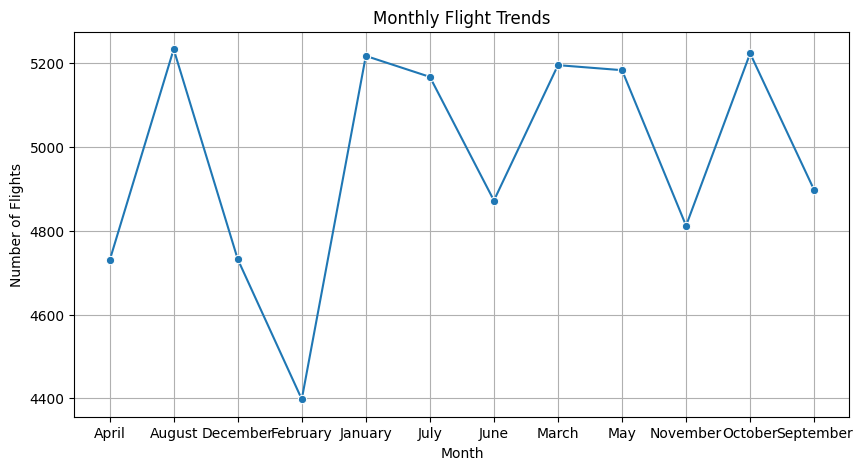

In [31]:
monthly_flights = df.groupby("Month").size()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_flights.index, y=monthly_flights.values, marker='o')
plt.title("Monthly Flight Trends")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.grid()
plt.show()


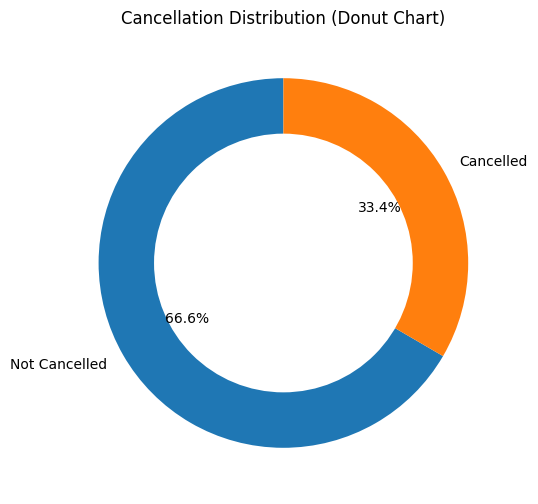

In [24]:
cancel_counts = df['IsCancelled'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(cancel_counts, labels=['Not Cancelled','Cancelled'],
        autopct='%1.1f%%', startangle=90)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Cancellation Distribution (Donut Chart)")
plt.show()

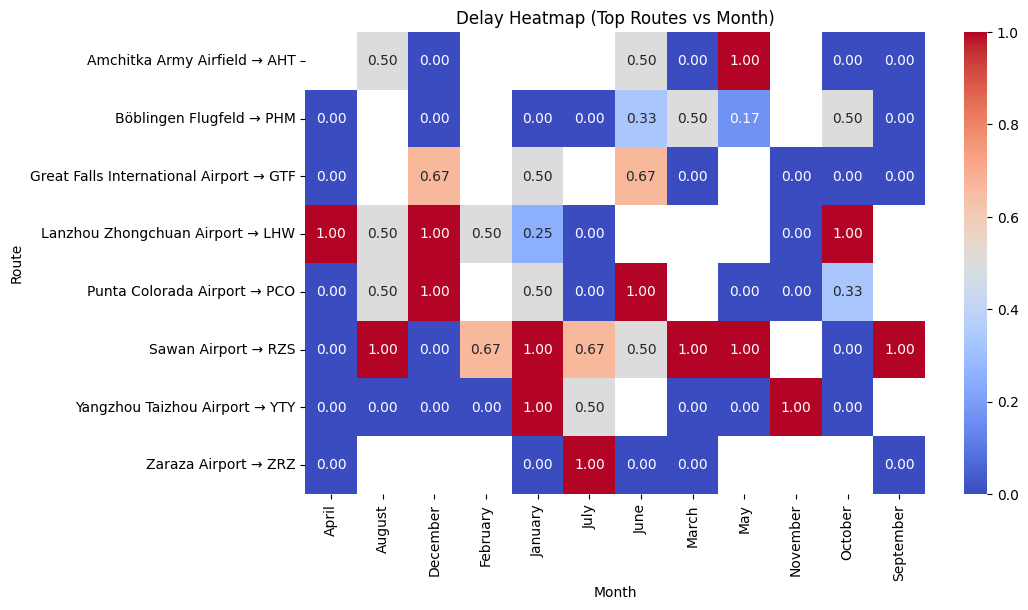

In [26]:
top_routes = df['Route'].value_counts().head(8).index
filtered_df = df[df['Route'].isin(top_routes)]

pivot = filtered_df.pivot_table(
    values='IsDelayed',
    index='Route',
    columns='Month',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Delay Heatmap (Top Routes vs Month)")
plt.show()

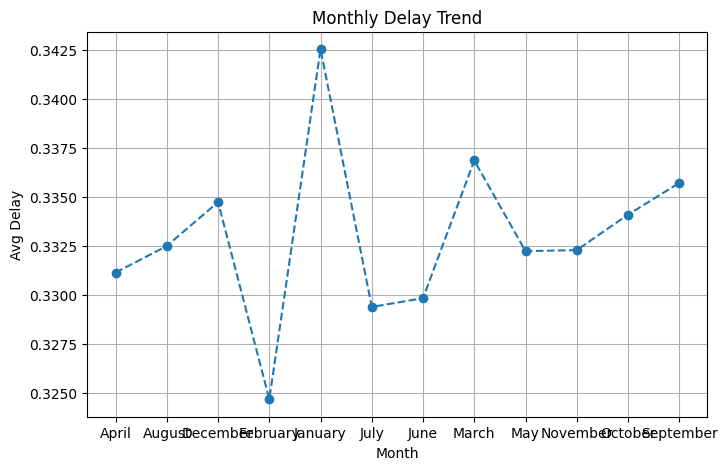

In [27]:
monthly_delay = df.groupby('Month')['IsDelayed'].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_delay, marker='o', linestyle='--')
plt.title("Monthly Delay Trend")
plt.xlabel("Month")
plt.ylabel("Avg Delay")
plt.grid()
plt.show()

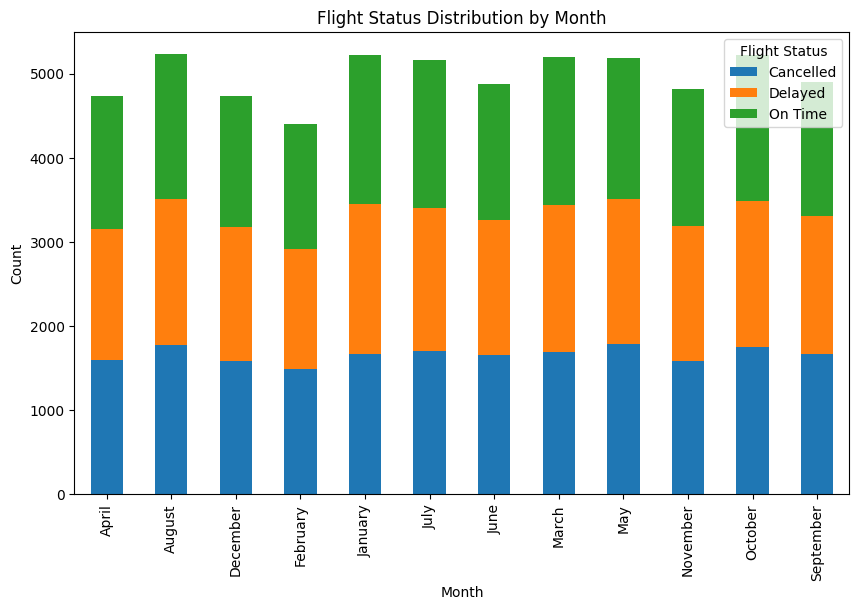

In [28]:
status_counts = df.groupby(['Month', 'Flight Status']).size().unstack()

status_counts.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Flight Status Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

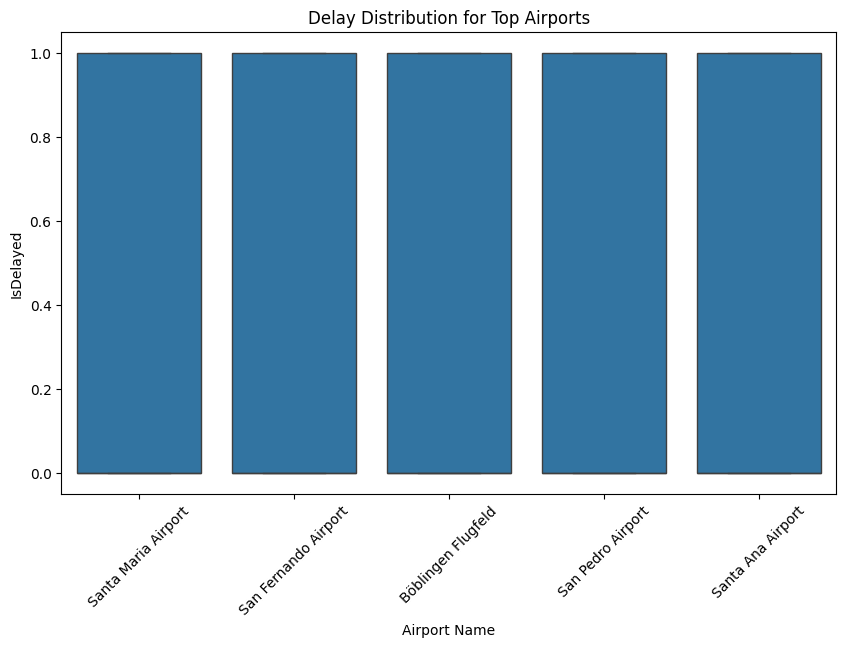

In [29]:
top_airports = df['Airport Name'].value_counts().head(5).index
filtered_df = df[df['Airport Name'].isin(top_airports)]

plt.figure(figsize=(10,6))
sns.boxplot(x='Airport Name', y='IsDelayed', data=filtered_df)
plt.title("Delay Distribution for Top Airports")
plt.xticks(rotation=45)
plt.show()

Monthly Cancellation Trends

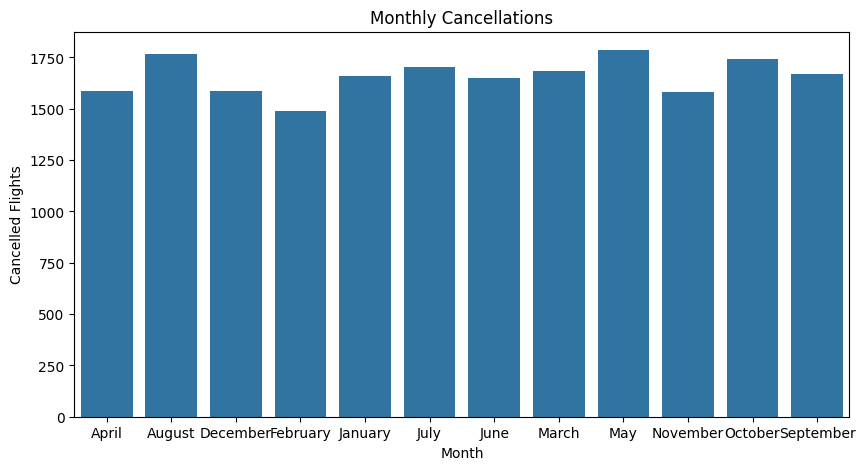

In [38]:
monthly_cancel = df.groupby("Month")["IsCancelled"].sum()

plt.figure(figsize=(10,5))
sns.barplot(x=monthly_cancel.index, y=monthly_cancel.values)

plt.title("Monthly Cancellations")
plt.xlabel("Month")
plt.ylabel("Cancelled Flights")
plt.show()

Cancellation Types

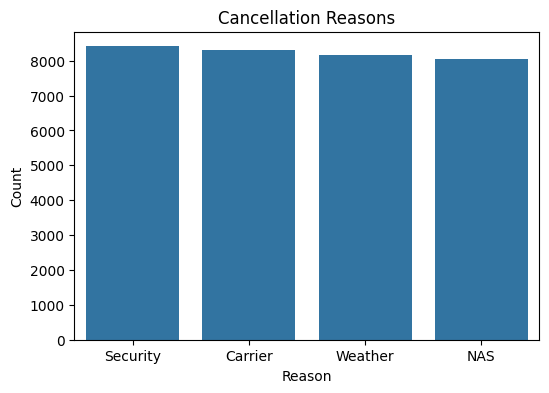

In [40]:
import numpy as np

# Create cancellation reasons (simulated)
reasons = ['Carrier', 'Weather', 'Security', 'NAS']
df['Cancel_Reason'] = np.where(
    df['IsCancelled'] == 1,
    np.random.choice(reasons, size=len(df)),
    'Not Cancelled'
)

# Count only cancelled flights
cancel_reason = df[df['IsCancelled'] == 1]['Cancel_Reason'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=cancel_reason.index, y=cancel_reason.values)

plt.title("Cancellation Reasons")
plt.xlabel("Reason")
plt.ylabel("Count")
plt.show()

In [42]:
df.to_csv("milestone3_analysis.csv", index=False)

In [44]:
print("Milestone 3 Completed ✅")

Milestone 3 Completed ✅
